# Invasion analyses

We used [invasion.ipynb](invasion.ipynb) to generate the data in
[figure2_data.csv](figure2_data.csv).  We now use these data to generate a
counterpart to figure 2 from the paper using these data.  Recall that these data
were obtained with lower replication than used for the version of figure 2 in
the paper ($n=10^4$ instead of $n=10^5$ per reproductive mode).  

The resulting figure is in [figure2_low_res.pdf](figure2_low_res.pdf).

## Data

In [1]:
import pandas as pd
import matplotlib as mpl
mpl.rcParams['font.family'] = "Helvetica"
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")

In [21]:
data = pd.read_csv('figure2_data.csv')
data

,mode,nfix,n,pfix,SE,lower,upper
0,asex,65,10000,0.0065,0.000804,0.004925,0.008075
1,sex,8,10000,0.0008,0.000283,0.000246,0.001354
2,r=0.25,9,10000,0.0009,0.000300,0.000312,0.001488
3,r=0.1,20,10000,0.0020,0.000447,0.001124,0.002876
4,r=0.05,19,10000,0.0019,0.000436,0.001046,0.002754
5,r=0.025,23,10000,0.0023,0.000479,0.001361,0.003239
6,r=0.01,21,10000,0.0021,0.000458,0.001203,0.002997
7,r=0.005,20,10000,0.0020,0.000447,0.001124,0.002876
8,r=0.0025,34,10000,0.0034,0.000582,0.002259,0.004541
9,r=0.001,34,10000,0.0034,0.000582,0.002259,0.004541


## Figure

In [17]:
modes = {'asex': [.0001, sns.xkcd_rgb['red'], "Obl. asex"], 
         'sex': [1, sns.xkcd_rgb['blue'], "Obl. sex"],
         'r=0': [.0001, sns.xkcd_rgb['sky blue']]}
for tau in [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]:
    phi = 1/tau
    modes.update({f"tau={tau}": [phi, sns.xkcd_rgb['light purple']]})
    r = .5/tau
    modes.update({f"r={r}": [phi, sns.xkcd_rgb['sky blue']]})
modes["tau=2"].append("Fac. sex")
modes["r=0.25"].append(r"Rescaled $r$")

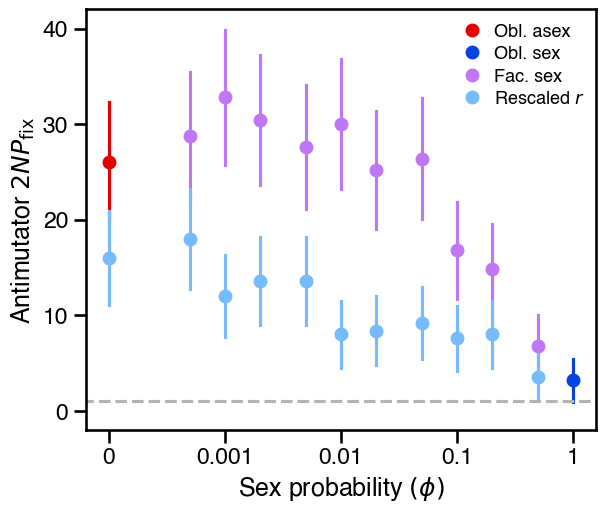

In [ ]:
fig = plt.figure(0, figsize=(6, 5))
for mode in modes:
    tmp = data.loc[data['mode']==mode,]
    plt.plot([modes[mode][0]] * 2, [tmp['lower']*4000, tmp['upper']*4000], color=modes[mode][1])
    if mode in ["asex", "sex", "tau=2", "r=0.25"]:
        plt.semilogx(modes[mode][0], tmp['pfix']*4000, 'o', color=modes[mode][1], label=modes[mode][2])
    else:
        plt.semilogx(modes[mode][0], tmp['pfix']*4000, 'o', color=modes[mode][1])
plt.plot([.00001,10], [1] * 2, '--', color="0.7")
plt.xticks([.0001,.001,.01, .1, 1], [0, 0.001, 0.01, 0.1 , 1])
plt.xlim(10**-4.2, 10**.2)
plt.ylim(-2, 42)
plt.yticks([0, 10, 20, 30, 40])
plt.xlabel(r'Sex probability $(\phi)$')
plt.ylabel(r'Antimutator $2NP_\text{fix}$')
plt.legend(loc=[.707,.75], fontsize=13, labelspacing=.3, handletextpad=.2, frameon=False)
plt.minorticks_off()
plt.tight_layout(pad=0.1)
fig.savefig("figure2_low_res.pdf")

In [27]:
!open .